## Install Packages

In [1]:
# !pip install contextily


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# packages
# from google.colab import files
import io
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import seaborn as sns
import contextily as ctx
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches

## Upload Clean Policing Dataset

In [5]:
sopp_df = pd.read_csv('../clean_datasets/sopp_df_3_8.csv')

/var/folders/n5/4t9x0f4j03n9b1tg992_l4lc0000gn/T/ipykernel_57925/909028622.py:1: DtypeWarning: Columns (8,10,17,18,19,24,25,26,27,31,32,33,34,35,37,38,39,40,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  sopp_df = pd.read_csv('../clean_datasets/sopp_df_3_8.csv')


## Create HeatMap

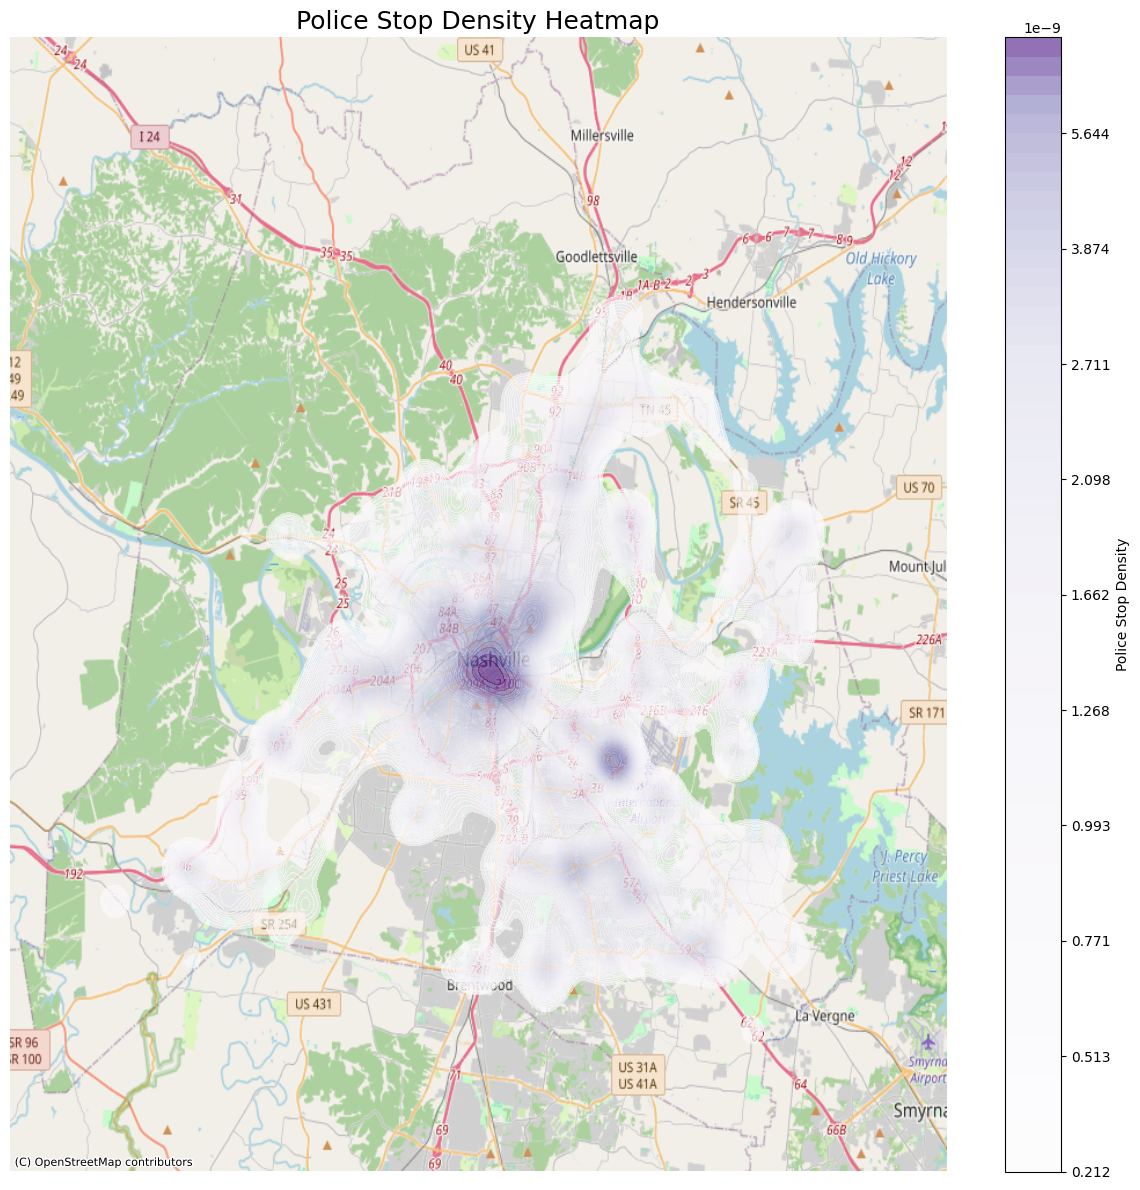

In [7]:
# create a GeoDataFrame from the police data
gdf = gpd.GeoDataFrame(
    sopp_df,
    geometry=gpd.points_from_xy(sopp_df.lng, sopp_df.lat),
    crs="EPSG:4326")

# reproject the data to Web Mercator (EPSG:3857), required to work with OpenStreetMap
gdf_web_mercator = gdf.to_crs(epsg=3857)

# extract x and y coordinates
x = gdf_web_mercator.geometry.x
y = gdf_web_mercator.geometry.y

# create figure and axis
fig, ax = plt.subplots(figsize=(12, 12))

# create heatmap
kde = sns.kdeplot(
    data=gdf_web_mercator,
    x=gdf_web_mercator.geometry.x,
    y=gdf_web_mercator.geometry.y,
    fill=True,
    cmap="Purples",
    levels=60,
    alpha=0.6,
    cbar=True,
    ax=ax
)

# format appropriately
cbar = kde.collections[0].colorbar
cbar.set_label("Police Stop Density")
cbar.formatter.set_powerlimits((0,0))
cbar.update_ticks()

# add base map
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Police Stop Density Heatmap", fontsize=18)
plt.tight_layout()
plt.savefig('../results/Police_Stop_Density_Heatmap.png', bbox_inches='tight', facecolor='white')
plt.show()